In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

In [2]:
raw = pd.read_excel('data/GuttmacherInstituteAbortionDataByState.xlsx', sheet_name='Guttmacher', engine='openpyxl')
raw.columns = raw.columns.str.strip() # remove whitespace from column names
raw.head()

,U.S. State,"% change in abortion rate, 2017-2020","% change in the no. of abortion clinics, 2017-2020","% change in the no. of abortion providers, 2014-2017","% of all U.S. abortions, by state of occurrence, 2020","% of counties without a known abortion provider, 2014","% of counties without a known clinic, 2020","% of residents obtaining abortions who traveled out of state for care, 2020","% of women aged 15-44 living in a county without a clinic, 2020","% of women aged 15-44 living in a county without an abortion provider, 2014",...,"No. of abortions per 1,000 women aged 15–44, by state of occurrence, 2020","No. of abortions per 1,000 women aged 15–44, by state of residence, 2020","No. of abortions, by state of occurrence, 2020","No. of abortions, by state of residence, 2020","No. of federally funded abortions, 2010","No. of state funded abortions, 2010","Reported public expenditures for abortions (in 000s of dollars), federal, 2015","Reported public expenditures for abortions (in 000s of dollars), state, 2015","Total no. of publicly funded abortions , 2010","Total reported public expenditures for abortions (in 000s of dollars), 2015"
0,Alabama,-6,0,-22,0.6,91,93,47,59,58,...,6.0,9.5,5700,9060,9,0,22,0,9,22
1,Alaska,0,0,-25,0.1,79,87,7,33,17,...,8.6,9.2,1240,1320,0,835,0,216,835,216
2,Arizona,1,0,-8,1.4,80,80,6,18,19,...,9.3,9.7,13320,13820,1,13,28,11,14,40
3,Arkansas,2,-33,0,0.3,97,99,37,86,77,...,5.6,7.8,3250,4510,0,0,0,0,0,0
4,California,17,7,-18,16.6,24,38,0,3,1,...,19.2,19.0,154060,152400,0,88466,0,32613,88466,32613


<h3>Data Cleaning</h3>

In [3]:
# convert all non numeric data to np.nan
for col in raw.columns[1:]:
    raw[col] = pd.to_numeric(raw[col], errors='coerce')

All categories come from: <a href="https://www.guttmacher.org/article/2018/01/policy-trends-states-2017">Guttmacher</a>

In [4]:
extremely_hostile_states = [
    "Alabama", "Arkansas", "Georgia", "Indiana", "Iowa", "Kansas", "Kentucky",
    "Louisiana", "Mississippi", "Missouri", "Nebraska", "North Carolina",
    "North Dakota", "Ohio", "Oklahoma", "South Carolina", "South Dakota",
    "Tennessee", "Texas", "Utah", "West Virginia", "Wisconsin", "Wyoming"
]

hostile_states = [
    "Idaho", "Michigan", "Pennsylvania", "Virginia"
]

middle_ground_states = [
    "Alaska", "Colorado", "Montana", "Nevada", "New Mexico", "North Dakota", "West Virginia"
]

illegal = extremely_hostile_states + hostile_states + middle_ground_states

uncategorized_states = [
    "Arizona", "California", "Connecticut", "Delaware", "District of Columbia",
    "Florida", "Hawaii", "Illinois", "Maine", "Maryland", "Massachusetts",
    "Minnesota", "New Hampshire", "New Jersey", "New York", "Oregon",
    "Rhode Island", "Vermont", "Washington"
]

for i, state in enumerate(raw['U.S. State']):
    if state in illegal:
        raw.iloc[i] = raw.iloc[i].fillna(0)

In [5]:
mask = raw['U.S. State'].isin(uncategorized_states)

for col in raw.columns:
    if col != 'U.S. State':
        mean_value = raw.loc[mask, col].mean(skipna=True)
        raw.loc[mask, col] = raw.loc[mask, col].fillna(mean_value)

In [8]:
df = raw.copy()

<h3>Supporting Abortion Access</h3>

“Access to abortion clinics is essential for reducing out-of-state travel and improving healthcare equity.”

In [13]:
def classify_state(state):
    if state in extremely_hostile_states:
        return 'Extremely Hostile'
    elif state in hostile_states:
        return 'Hostile'
    elif state in middle_ground_states:
        return 'Middle Ground'
    elif state in uncategorized_states:
        return 'Uncategorized'
    else:
        return 'Unknown'

custom_palette = {
    'Extremely Hostile': '#E63946',  # Bright Red
    'Hostile': '#F4A261',            # Warm Orange
    'Middle Ground': '#2A9D8F',      # Teal Green
    'Uncategorized': '#264653'       # Deep Blue-Green
}

df['Policy Category'] = df['U.S. State'].apply(classify_state)

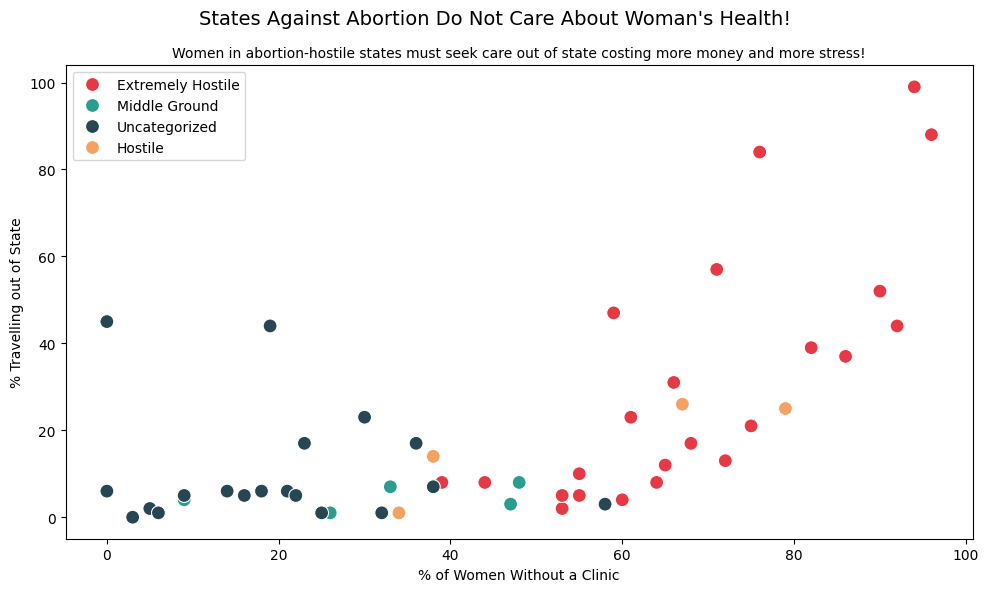

In [48]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='% of women aged 15-44 living in a county without a clinic, 2020',
    y='% of residents obtaining abortions who traveled out of state for care, 2020',
    hue='Policy Category',
    palette=custom_palette, #2
    s=100
)

plt.suptitle("States Against Abortion Do Not Care About Woman's Health!", fontsize=14) #-1
plt.title('Women in abortion-hostile states must seek care out of state costing more money and more stress!', fontsize=10)
plt.ylabel('% Travelling out of State')
plt.xlabel('% of Women Without a Clinic')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

**Possible Argument**: *Lack of local clinics correlates with increased out-of-state travel.*

- There’s a clear upward trend: as the % of women without a local clinic increases, so does the % travelling out of state.

- Especially in "Extremely Hostile" states, the more women lack local access, the more likely they are to leave the state for care.

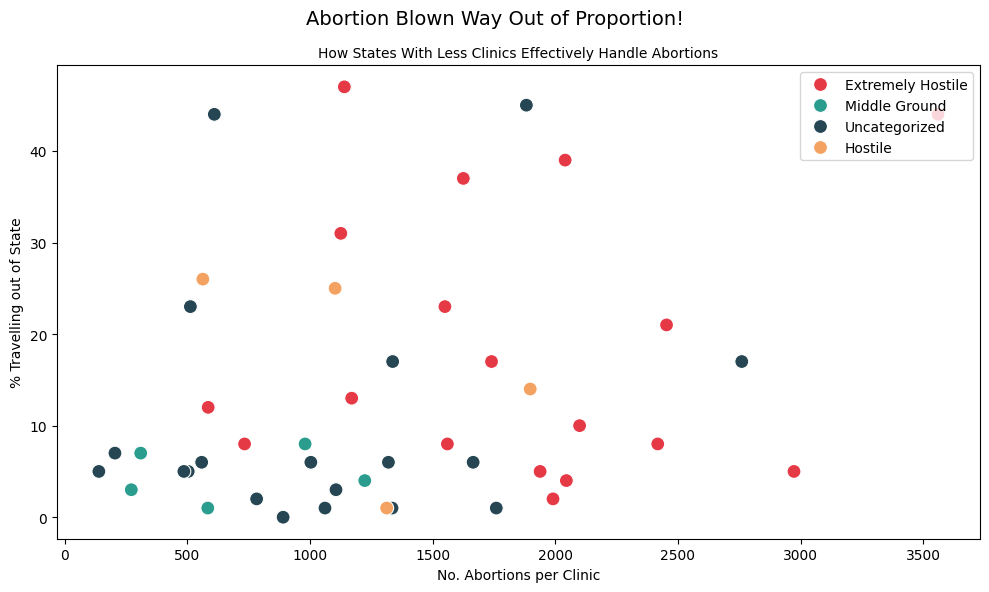

In [43]:
df['No. of abortions by state of occurence per No. of abortion clinics'] =df['No. of abortions, by state of occurrence, 2020'] /df['No. of abortion clinics, 2020'] #0

plt.figure(figsize=(10, 6))

filtered_df = df[df['% of residents obtaining abortions who traveled out of state for care, 2020'] < 50] #-2

sns.scatterplot(
    data=filtered_df,
    x='No. of abortions by state of occurence per No. of abortion clinics',
    y='% of residents obtaining abortions who traveled out of state for care, 2020',
    hue='Policy Category',
    palette=custom_palette, #2
    s=100  
)

plt.suptitle('Abortion Blown Way Out of Proportion!', fontsize=14)
plt.title('How States With Less Clinics Effectively Handle Abortions', fontsize=10)
plt.ylabel('% Travelling out of State')
plt.xlabel('No. Abortions per Clinic')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

**Possible Argument**: *Clinic efficiency matters more than just access.*

- Some states (especially "Extremely Hostile" ones) show very high abortion volume per clinic yet low out-of-state travel. This suggests that even a small number of clinics may serve residents effectively if they are high-capacity or strategically located.

- Uncategorized and Middle Ground states also cluster at low travel rates despite varying clinic burdens, complicating a simple access = equity argument.